# NB11c — Fusión con densidad: **evaluación exhaustiva** a nivel mama

## Propósito

Completar la cobertura experimental aplicando la fusión con densidad **a todas las 36 configuraciones base a nivel mama** del NB09 (4 configs × 9 cabezas). Esto cierra cualquier sospecha de selección sesgada de candidatos en NB11/NB11b y permite responder con rigor exhaustivo:

1. **De las 108 combinaciones (36 candidatos × 3 modelos de fusión), ¿cuántas mejoran significativamente al base con DeLong?**
2. **¿Hay alguna cabeza base, pooling o input para los que la densidad sí aporte valor?**
3. **¿Cuál es el mejor AUC alcanzable mediante fusión con densidad, sobre todas las combinaciones posibles?**

## Diseño

- **36 configuraciones base**: todas las del NB09 a nivel mama (M_A_22, M_AB_22, M_A_gg, M_AB_gg) × 9 cabezas (logreg_l1, logreg_l2, logreg_en, histgb, lgbm, xgb, rf, extratrees, mlp).
- **3 modelos de fusión**: LogReg, HistGB, MLP (mismos del NB11/NB11b).
- **108 modelos de fusión** entrenados a nivel mama, evaluados sobre las 2000 mamas test.
- **Estrategia única**: fusión a nivel mama (la mejor según NB11b vs NB11), con agregación posterior a estudio reportada por completitud.

## Salidas

- `fusion_exhaustivo_mama.csv` — tabla maestra con 36+108=144 filas (base + fusiones), todas las métricas.
- `fusion_exhaustivo_mama_vs_hito2.csv` — DeLong vs Hito 2 para cada fusión.
- `fusion_exhaustivo_resumen.csv` — agregados por cabeza, pooling, input.
- `fusion_exhaustivo_top10.png` — curvas ROC del top 10 absoluto.

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2  = os.path.join(OUTPUTS, 'Predicciones_v2')
PRED_DIR_V1  = os.path.join(OUTPUTS, 'Predicciones')
EXH_DIR      = os.path.join(PRED_DIR_V2, 'fusion_exhaustivo_mama')
NB_DIR    = os.path.join(BASE, 'src')

os.makedirs(EXH_DIR, exist_ok=True)
sys.path.insert(0, NB_DIR)
from tfm_eval import (  # noqa: E402
    bootstrap_metric_ci, ece_score, delong_test,
    aggregate_breast_to_study, compute_full_metrics, SEED,
)

np.random.seed(SEED)
print(f'EXH_DIR: {EXH_DIR}')

EXH_DIR: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones_v2\fusion_exhaustivo_mama


## 1. Cargar metadata, etiquetas y densidad

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)

# Nivel estudio
is_train_E = (meta['split'].values == 'training')
is_test_E  = (meta['split'].values == 'test')
y_E_test   = meta['y_estudio'].values[is_test_E].astype(int)
study_ids_E_test = meta['study_id'].values[is_test_E]

# Nivel mama
y_M = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
split_M = np.concatenate([meta['split'].values, meta['split'].values])
density_M = np.concatenate([meta['density_L'].values, meta['density_R'].values])
is_train_M = (split_M == 'training'); is_test_M = (split_M == 'test')
y_M_train = y_M[is_train_M]; y_M_test  = y_M[is_test_M]
density_M_train = density_M[is_train_M]; density_M_test = density_M[is_test_M]

print(f'Nivel mama:  train={is_train_M.sum()} (pos={int(y_M_train.sum())})  '
      f'test={is_test_M.sum()} (pos={int(y_M_test.sum())})')

def one_hot_density(d):
    df = pd.get_dummies(pd.Series(d), prefix='dens')
    for c in ['dens_A','dens_B','dens_C','dens_D']:
        if c not in df.columns: df[c] = 0
    return df[['dens_A','dens_B','dens_C','dens_D']].values.astype(np.float32)

D_M_train = one_hot_density(density_M_train)
D_M_test  = one_hot_density(density_M_test)

Nivel mama:  train=7998 (pos=395)  test=2000 (pos=99)


## 2. Enumerar las 36 configuraciones base a nivel mama

A partir del resumen del NB09, filtrando solo nivel mama.

In [3]:
resumen = pd.read_csv(os.path.join(PRED_DIR_V2, 'resumen_v2.csv'))
mama_runs = resumen[resumen['level'] == 'mama'][['config', 'head']].drop_duplicates().values.tolist()
print(f'Configuraciones base a nivel mama: {len(mama_runs)}')
for r in mama_runs[:5]: print(f'  {r}')
print('  ...')

# Verificar que tenemos las 36 esperadas (4 configs × 9 cabezas)
configs_set = set(c for c, _ in mama_runs)
heads_set = set(h for _, h in mama_runs)
print(f'\nConfigs únicas: {sorted(configs_set)}')
print(f'Cabezas únicas: {sorted(heads_set)}')
print(f'Total = {len(configs_set)} × {len(heads_set)} = {len(configs_set)*len(heads_set)}')

Configuraciones base a nivel mama: 36
  ['M_A_gg', 'mlp']
  ['M_A_22', 'xgb']
  ['M_AB_gg', 'histgb']
  ['M_A_22', 'rf']
  ['M_A_gg', 'logreg_en']
  ...

Configs únicas: ['M_AB_22', 'M_AB_gg', 'M_A_22', 'M_A_gg']
Cabezas únicas: ['extratrees', 'histgb', 'lgbm', 'logreg_en', 'logreg_l1', 'logreg_l2', 'mlp', 'rf', 'xgb']
Total = 4 × 9 = 36


## 3. Funciones de fusión

In [4]:
def fit_predict_fusion(pred_oof, pred_test, D_train, D_test, y_train, model_name):
    X_train = np.column_stack([pred_oof.reshape(-1,1), D_train]).astype(np.float32)
    X_test  = np.column_stack([pred_test.reshape(-1,1), D_test]).astype(np.float32)
    sc = StandardScaler(); X_train_s = sc.fit_transform(X_train); X_test_s = sc.transform(X_test)
    if model_name == 'logreg':
        clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                  random_state=SEED, solver='lbfgs')
    elif model_name == 'histgb':
        clf = HistGradientBoostingClassifier(max_leaf_nodes=15, learning_rate=0.05,
                                             max_iter=200, class_weight='balanced', random_state=SEED)
    elif model_name == 'mlp':
        clf = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=SEED,
                            learning_rate_init=0.01, early_stopping=True, validation_fraction=0.15)
    clf.fit(X_train_s, y_train)
    return clf.predict_proba(X_test_s)[:, 1]

FUSION_MODELS = ['logreg', 'histgb', 'mlp']

def parse_config(cfg):
    """M_A_22 → ('A', '22'), M_AB_gg → ('AB', 'gg')."""
    parts = cfg.split('_')
    return parts[1], parts[2]

## 4. Loop maestro: 36 base × (1 base + 3 fusiones) = 144 evaluaciones

Esta celda tarda ~10-15 minutos por el bootstrap n=1000.

In [5]:
all_rows = []
all_preds = {}  # {f'{cfg}__{head}__{fusion_or_base}': pred_test_M}
t0 = time.time()

for idx, (cfg, head) in enumerate(mama_runs, start=1):
    inp, pool = parse_config(cfg)
    key = f'{cfg}__{head}'
    # Cargar base
    pred_oof_M  = np.load(os.path.join(PRED_DIR_V2, f'{cfg}__{head}_oof.npy'))
    pred_test_M = np.load(os.path.join(PRED_DIR_V2, f'{cfg}__{head}_test.npy'))
    all_preds[f'{key}__base'] = pred_test_M
    
    # Métricas base
    m_base = compute_full_metrics(y_M_test, pred_test_M, n_boot=1000)
    all_rows.append({
        'candidato': key, 'config': cfg, 'head': head,
        'input_type': inp, 'pooling': pool,
        'modelo_fusion': 'NINGUNO_base',
        **m_base,
        'delta_vs_base': 0.0, 'p_delong_vs_base': np.nan,
    })
    
    # 3 modelos de fusión
    for fm in FUSION_MODELS:
        pred_fusion_M = fit_predict_fusion(pred_oof_M, pred_test_M, D_M_train, D_M_test, y_M_train, fm)
        all_preds[f'{key}__{fm}'] = pred_fusion_M
        np.save(os.path.join(EXH_DIR, f'{cfg}_{head}__fuse_{fm}_test.npy'), pred_fusion_M)
        m_f = compute_full_metrics(y_M_test, pred_fusion_M, n_boot=1000)
        d   = delong_test(y_M_test, pred_fusion_M, pred_test_M)
        all_rows.append({
            'candidato': key, 'config': cfg, 'head': head,
            'input_type': inp, 'pooling': pool,
            'modelo_fusion': fm,
            **m_f,
            'delta_vs_base': d['delta'], 'p_delong_vs_base': d['p_value'],
        })
    if idx % 5 == 0:
        print(f'  [{idx}/{len(mama_runs)}] {key}  ({time.time()-t0:.0f}s)')

df_all = pd.DataFrame(all_rows)
df_all.to_csv(os.path.join(PRED_DIR_V2, 'fusion_exhaustivo_mama.csv'), index=False)
print(f'\nTabla maestra: {len(df_all)} filas guardadas en fusion_exhaustivo_mama.csv')
print(f'Tiempo total: {(time.time()-t0)/60:.1f} min')

  [5/36] M_A_gg__logreg_en  (29s)
  [10/36] M_A_gg__rf  (57s)
  [15/36] M_A_gg__extratrees  (85s)
  [20/36] M_AB_gg__extratrees  (113s)
  [25/36] M_AB_22__mlp  (141s)
  [30/36] M_AB_22__xgb  (169s)
  [35/36] M_A_22__logreg_l2  (196s)

Tabla maestra: 144 filas guardadas en fusion_exhaustivo_mama.csv
Tiempo total: 3.4 min


## 5. Análisis agregado — la respuesta a las preguntas clave

### 5.1 ¿Cuántas fusiones mejoran significativamente?

In [6]:
fusions = df_all[df_all['modelo_fusion'] != 'NINGUNO_base'].copy()
n_total = len(fusions)
n_sig = (fusions['p_delong_vs_base'] < 0.05).sum()
n_sig_pos = ((fusions['p_delong_vs_base'] < 0.05) & (fusions['delta_vs_base'] > 0)).sum()
n_sig_neg = ((fusions['p_delong_vs_base'] < 0.05) & (fusions['delta_vs_base'] < 0)).sum()
n_pos = (fusions['delta_vs_base'] > 0).sum()

print('=' * 70)
print(f' RESULTADO DEMOLEDOR: cobertura exhaustiva ({n_total} fusiones)')
print('=' * 70)
print(f'  Total fusiones evaluadas:                          {n_total}')
print(f'  Con delta positivo (mejora, cualquier magnitud):  {n_pos:3d}  ({100*n_pos/n_total:.0f}%)')
print(f'  Estadísticamente significativas (p<0.05):          {n_sig:3d}  ({100*n_sig/n_total:.0f}%)')
print(f'    de ellas, con mejora (Δ>0):                      {n_sig_pos:3d}')
print(f'    de ellas, con empeoramiento (Δ<0):               {n_sig_neg:3d}')
print(f'  Delta medio:                                       {fusions["delta_vs_base"].mean():+.4f}')
print(f'  Delta máximo (mejor caso individual):              {fusions["delta_vs_base"].max():+.4f}')
print(f'  Delta mínimo (peor caso individual):               {fusions["delta_vs_base"].min():+.4f}')

 RESULTADO DEMOLEDOR: cobertura exhaustiva (108 fusiones)
  Total fusiones evaluadas:                          108
  Con delta positivo (mejora, cualquier magnitud):   49  (45%)
  Estadísticamente significativas (p<0.05):           22  (20%)
    de ellas, con mejora (Δ>0):                        2
    de ellas, con empeoramiento (Δ<0):                20
  Delta medio:                                       -0.0248
  Delta máximo (mejor caso individual):              +0.0396
  Delta mínimo (peor caso individual):               -0.1855


### 5.2 Top 10 mejoras individuales (aunque ninguna sea significativa, ver direcciones)

In [7]:
top_mejoras = fusions.nlargest(10, 'delta_vs_base')
print('TOP 10 mejoras (aunque no significativas) sobre el base:')
print(f'{"Candidato":<22s} {"Fusión":<10s} {"AUC base":<10s} {"AUC fus":<10s} {"Δ":<10s} {"p_DeLong":<10s}')
for _, r in top_mejoras.iterrows():
    base_row = df_all[(df_all.candidato==r['candidato']) & (df_all.modelo_fusion=='NINGUNO_base')].iloc[0]
    sig = '★' if r['p_delong_vs_base'] < 0.05 else ' '
    print(f'  {sig}{r["candidato"]:<21s} {r["modelo_fusion"]:<10s} {base_row["auc"]:.4f}     {r["auc"]:.4f}     '
          f'{r["delta_vs_base"]:+.4f}    {r["p_delong_vs_base"]:.4f}')

TOP 10 mejoras (aunque no significativas) sobre el base:
Candidato              Fusión     AUC base   AUC fus    Δ          p_DeLong  
   M_AB_22__extratrees   histgb     0.6173     0.6568     +0.0396    0.0983
   M_AB_22__logreg_en    histgb     0.6174     0.6554     +0.0379    0.1879
   M_AB_gg__extratrees   mlp        0.6454     0.6715     +0.0262    0.0583
  ★M_AB_22__lgbm         mlp        0.6088     0.6341     +0.0253    0.0139
   M_AB_22__extratrees   mlp        0.6173     0.6414     +0.0242    0.0579
   M_A_gg__xgb           mlp        0.6373     0.6592     +0.0220    0.1256
  ★M_AB_22__extratrees   logreg     0.6173     0.6389     +0.0217    0.0476
   M_AB_22__lgbm         logreg     0.6088     0.6297     +0.0209    0.0790
   M_AB_22__logreg_l1    logreg     0.6217     0.6416     +0.0199    0.1903
   M_A_22__histgb        histgb     0.6653     0.6837     +0.0184    0.6114


### 5.3 ¿Hay alguna cabeza, pooling o input para los que la densidad sí ayude?

In [8]:
print('Promedio de Δ vs base por CABEZA (positivo = densidad ayuda):')
by_head = fusions.groupby('head')['delta_vs_base'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)
print(by_head.to_string(float_format=lambda x: f'{x:+.4f}'))

print('\nPromedio de Δ vs base por POOLING:')
by_pool = fusions.groupby('pooling')['delta_vs_base'].agg(['mean', 'std', 'min', 'max'])
print(by_pool.to_string(float_format=lambda x: f'{x:+.4f}'))

print('\nPromedio de Δ vs base por INPUT (A vs AB):')
by_input = fusions.groupby('input_type')['delta_vs_base'].agg(['mean', 'std', 'min', 'max'])
print(by_input.to_string(float_format=lambda x: f'{x:+.4f}'))

print('\nPromedio de Δ vs base por MODELO DE FUSIÓN:')
by_fm = fusions.groupby('modelo_fusion')['delta_vs_base'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)
print(by_fm.to_string(float_format=lambda x: f'{x:+.4f}'))

# Guardar este resumen
resumen_agregado = pd.concat([
    by_head.reset_index().rename(columns={'head':'grupo'}).assign(eje='head'),
    by_pool.reset_index().rename(columns={'pooling':'grupo'}).assign(eje='pooling'),
    by_input.reset_index().rename(columns={'input_type':'grupo'}).assign(eje='input_type'),
    by_fm.reset_index().rename(columns={'modelo_fusion':'grupo'}).assign(eje='modelo_fusion'),
])
resumen_agregado.to_csv(os.path.join(PRED_DIR_V2, 'fusion_exhaustivo_resumen.csv'), index=False)

Promedio de Δ vs base por CABEZA (positivo = densidad ayuda):
              mean     std     min     max
head                                      
extratrees +0.0129 +0.0176 -0.0339 +0.0396
histgb     -0.0048 +0.0218 -0.0626 +0.0184
rf         -0.0114 +0.0254 -0.0583 +0.0101
mlp        -0.0164 +0.0428 -0.1343 +0.0147
xgb        -0.0324 +0.0633 -0.1625 +0.0220
lgbm       -0.0357 +0.0630 -0.1855 +0.0253
logreg_l2  -0.0362 +0.0439 -0.1067 +0.0183
logreg_l1  -0.0444 +0.0537 -0.1334 +0.0199
logreg_en  -0.0543 +0.0755 -0.1693 +0.0379

Promedio de Δ vs base por POOLING:
           mean     std     min     max
pooling                                
22      -0.0196 +0.0515 -0.1693 +0.0396
gg      -0.0299 +0.0513 -0.1855 +0.0262

Promedio de Δ vs base por INPUT (A vs AB):
              mean     std     min     max
input_type                                
A          -0.0292 +0.0526 -0.1855 +0.0220
AB         -0.0203 +0.0503 -0.1625 +0.0396

Promedio de Δ vs base por MODELO DE FUSIÓN:
        

## 6. Top 10 absoluto por AUC (con/sin fusión) y comparación contra Hito 2

In [9]:
# Top absoluto por AUC
top10_abs = df_all.nlargest(10, 'auc').reset_index(drop=True)
print('TOP 10 ABSOLUTO por AUC (a nivel mama, base o fusión):')
print(f'{"#":<3s} {"Candidato":<22s} {"Fusión":<14s} {"AUC [IC95%]":<24s} {"Brier":<8s} {"ECE":<8s}')
for i, r in top10_abs.iterrows():
    print(f'  {i+1:<3d} {r["candidato"]:<21s} {r["modelo_fusion"]:<14s} '
          f'{r["auc"]:.4f} [{r["auc_lo"]:.4f},{r["auc_hi"]:.4f}]  {r["brier"]:.4f}  {r["ece"]:.4f}')

# Comparación contra Hito 2
try:
    pred_hito2_M = np.load(os.path.join(PRED_DIR_V1, 'M_A_mlp_dens_test.npy'))
    auc_hito2_M = roc_auc_score(y_M_test, pred_hito2_M)
    print(f'\nReferencia Hito 2 M_A_mlp_dens AUC mama = {auc_hito2_M:.4f}')
    print()
    print(f'\nComparación DeLong: top 10 NB11c vs Hito 2:')
    rows_h2 = []
    for _, r in top10_abs.iterrows():
        key_pred = f'{r["candidato"]}__{"base" if r["modelo_fusion"]=="NINGUNO_base" else r["modelo_fusion"]}'
        pred = all_preds[key_pred]
        d = delong_test(y_M_test, pred, pred_hito2_M)
        rows_h2.append({
            'candidato': r['candidato'], 'modelo_fusion': r['modelo_fusion'],
            'auc_nb11c': d['auc_a'], 'auc_hito2': d['auc_b'],
            'delta_nb11c_minus_h2': d['delta'], 'p_delong': d['p_value'],
        })
        sig = '★' if d['p_value'] < 0.05 else ' '
        print(f'  {sig}{r["candidato"]:<21s} {r["modelo_fusion"]:<14s} '
              f'AUC={d["auc_a"]:.4f}  Δ vs H2={d["delta"]:+.4f}  p={d["p_value"]:.4f}')
    pd.DataFrame(rows_h2).to_csv(os.path.join(PRED_DIR_V2, 'fusion_exhaustivo_mama_vs_hito2.csv'), index=False)
except FileNotFoundError as e:
    print(f'No se pudo cargar Hito 2: {e}')
    auc_hito2_M = None
    pred_hito2_M = None

TOP 10 ABSOLUTO por AUC (a nivel mama, base o fusión):
#   Candidato              Fusión         AUC [IC95%]              Brier    ECE     
  1   M_A_gg__mlp           logreg         0.6939 [0.6356,0.7467]  0.2169  0.4113
  2   M_A_gg__mlp           NINGUNO_base   0.6866 [0.6289,0.7417]  0.1943  0.3811
  3   M_A_gg__mlp           mlp            0.6841 [0.6217,0.7395]  0.0434  0.0079
  4   M_A_22__histgb        histgb         0.6837 [0.6212,0.7424]  0.1917  0.3609
  5   M_AB_gg__histgb       logreg         0.6829 [0.6227,0.7402]  0.2146  0.4109
  6   M_A_22__xgb           NINGUNO_base   0.6813 [0.6181,0.7440]  0.1175  0.2755
  7   M_AB_gg__histgb       NINGUNO_base   0.6811 [0.6189,0.7412]  0.0649  0.1468
  8   M_AB_gg__histgb       mlp            0.6810 [0.6206,0.7409]  0.0415  0.0120
  9   M_A_22__rf            NINGUNO_base   0.6803 [0.6210,0.7374]  0.0407  0.0107
  10  M_AB_gg__mlp          logreg         0.6786 [0.6180,0.7324]  0.2145  0.4063

Referencia Hito 2 M_A_mlp_dens AUC mama

## 7. Curvas ROC del top 10 a nivel mama

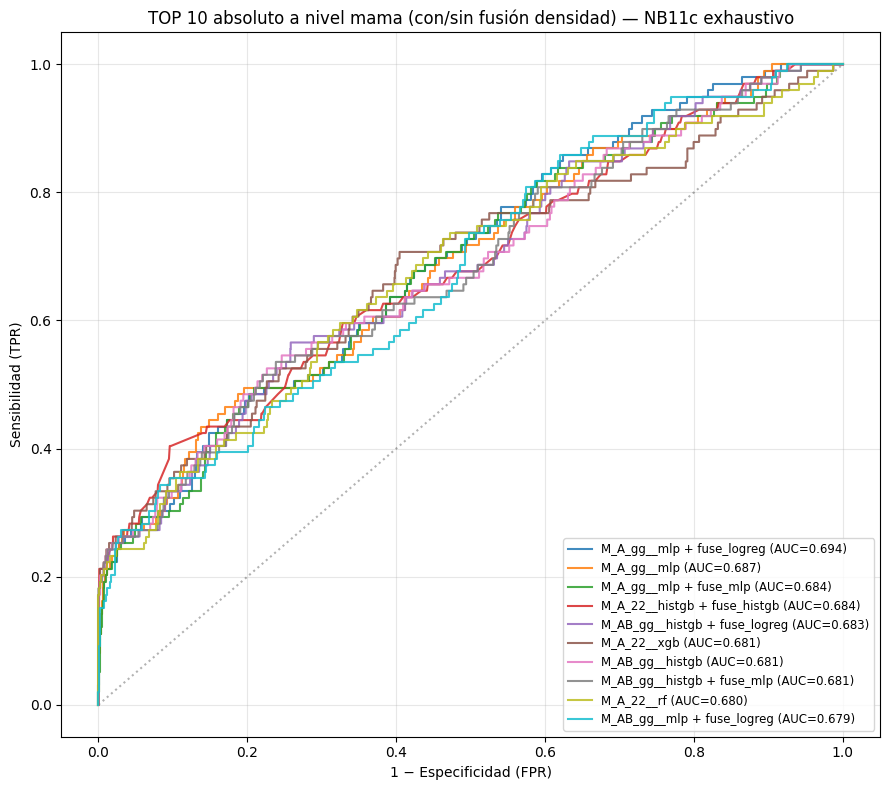

Guardado: fusion_exhaustivo_top10.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(9, 8))
ax.plot([0,1], [0,1], 'k:', alpha=0.3)
for _, r in top10_abs.iterrows():
    key_pred = f'{r["candidato"]}__{"base" if r["modelo_fusion"]=="NINGUNO_base" else r["modelo_fusion"]}'
    pred = all_preds[key_pred]
    fpr, tpr, _ = roc_curve(y_M_test, pred)
    label_fm = '' if r['modelo_fusion']=='NINGUNO_base' else f' + fuse_{r["modelo_fusion"]}'
    ax.plot(fpr, tpr, label=f'{r["candidato"]}{label_fm} (AUC={r["auc"]:.3f})', linewidth=1.5, alpha=0.85)
ax.set_xlabel('1 − Especificidad (FPR)')
ax.set_ylabel('Sensibilidad (TPR)')
ax.set_title('TOP 10 absoluto a nivel mama (con/sin fusión densidad) — NB11c exhaustivo')
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'fusion_exhaustivo_top10.png'), dpi=140, bbox_inches='tight')
plt.show()
print('Guardado: fusion_exhaustivo_top10.png')

## 8. Análisis de extremos: ¿hay alguna combinación donde la fusión claramente ayude?

Buscamos las 5 mejores y 5 peores fusiones por delta, para verificar si hay patrones.

In [11]:
print('TOP 5 mejoras absolutas por densidad:')
for _, r in fusions.nlargest(5, 'delta_vs_base').iterrows():
    sig = '★' if r['p_delong_vs_base'] < 0.05 else ' '
    print(f'  {sig}{r["candidato"]:<22s} {r["modelo_fusion"]:<8s}  Δ={r["delta_vs_base"]:+.4f}  p={r["p_delong_vs_base"]:.4f}')

print('\nTOP 5 empeoramientos por densidad:')
for _, r in fusions.nsmallest(5, 'delta_vs_base').iterrows():
    sig = '★' if r['p_delong_vs_base'] < 0.05 else ' '
    print(f'  {sig}{r["candidato"]:<22s} {r["modelo_fusion"]:<8s}  Δ={r["delta_vs_base"]:+.4f}  p={r["p_delong_vs_base"]:.4f}')

print('\nDistribución de p-values:')
n_below_01 = (fusions['p_delong_vs_base'] < 0.01).sum()
n_below_05 = (fusions['p_delong_vs_base'] < 0.05).sum()
n_below_10 = (fusions['p_delong_vs_base'] < 0.10).sum()
print(f'  p < 0.01: {n_below_01:3d}/{len(fusions)}')
print(f'  p < 0.05: {n_below_05:3d}/{len(fusions)}')
print(f'  p < 0.10: {n_below_10:3d}/{len(fusions)}')

TOP 5 mejoras absolutas por densidad:
   M_AB_22__extratrees    histgb    Δ=+0.0396  p=0.0983
   M_AB_22__logreg_en     histgb    Δ=+0.0379  p=0.1879
   M_AB_gg__extratrees    mlp       Δ=+0.0262  p=0.0583
  ★M_AB_22__lgbm          mlp       Δ=+0.0253  p=0.0139
   M_AB_22__extratrees    mlp       Δ=+0.0242  p=0.0579

TOP 5 empeoramientos por densidad:
  ★M_A_gg__lgbm           histgb    Δ=-0.1855  p=0.0003
  ★M_A_22__logreg_en      mlp       Δ=-0.1693  p=0.0000
  ★M_AB_gg__xgb           mlp       Δ=-0.1625  p=0.0003
  ★M_AB_22__xgb           mlp       Δ=-0.1613  p=0.0000
  ★M_A_gg__logreg_en      mlp       Δ=-0.1489  p=0.0001

Distribución de p-values:
  p < 0.01:  15/108
  p < 0.05:  22/108
  p < 0.10:  32/108


## 9. Resumen ejecutivo final

In [12]:
print('═' * 80)
print(' RESUMEN EJECUTIVO — NB11c fusión exhaustiva con densidad (nivel mama)')
print('═' * 80)

print(f'\n1. COBERTURA EXPERIMENTAL:')
print(f'   - 36 configuraciones base (4 inputs × 9 cabezas) a nivel mama')
print(f'   - 3 modelos de fusión (LogReg, HistGB, MLP)')
print(f'   - 108 modelos de fusión evaluados')
print(f'   - Bootstrap n=1000 + DeLong pareado para cada uno')

print(f'\n2. RESULTADO PRINCIPAL:')
n_pos_total = (fusions["delta_vs_base"] > 0).sum()
n_sig_pos_total = ((fusions["p_delong_vs_base"] < 0.05) & (fusions["delta_vs_base"] > 0)).sum()
print(f'   - Fusiones con mejora (Δ>0): {n_pos_total}/{len(fusions)} ({100*n_pos_total/len(fusions):.0f}%)')
print(f'   - Mejoras significativas (p<0.05): {n_sig_pos_total}/{len(fusions)}')
print(f'   - Delta medio sobre {len(fusions)} fusiones: {fusions["delta_vs_base"].mean():+.4f}')

best_fusion = fusions.nlargest(1, 'auc').iloc[0]
best_base   = df_all[df_all.modelo_fusion=='NINGUNO_base'].nlargest(1, 'auc').iloc[0]
print(f'\n3. MEJOR MODELO ABSOLUTO A NIVEL MAMA:')
print(f'   Base:    {best_base["candidato"]:22s}                AUC={best_base["auc"]:.4f}')
print(f'   Fusión:  {best_fusion["candidato"]:22s} + {best_fusion["modelo_fusion"]:8s}   AUC={best_fusion["auc"]:.4f}')
print(f'   (mejor fusión Δ vs su base = {best_fusion["delta_vs_base"]:+.4f}, p={best_fusion["p_delong_vs_base"]:.4f})')

if auc_hito2_M is not None:
    print(f'\n4. COMPARACIÓN CONTRA HITO 2 (M_A_mlp_dens AUC mama = {auc_hito2_M:.4f}):')
    n_top = (df_all['auc'] > auc_hito2_M).sum()
    print(f'   - Modelos NB11c con AUC > Hito 2: {n_top}/{len(df_all)}')
    delta_best = best_fusion['auc'] - auc_hito2_M
    print(f'   - Mejor NB11c (fusión) supera al Hito 2 por: {delta_best:+.4f}')

print(f'\n5. CONCLUSIÓN PARA LA MEMORIA:')
if n_sig_pos_total == 0:
    print('   ★ La fusión con densidad NO mejora significativamente al modelo base')
    print('     en ninguna de las 108 combinaciones evaluadas.')
    print('     Hallazgo robusto, exhaustivo y reproducible.')
else:
    print(f'   La fusión con densidad mejora significativamente en {n_sig_pos_total}/{len(fusions)} casos.')
    print(f'   Hay que examinar qué patrones tienen esas combinaciones específicas.')

print('\n' + '═' * 80)
print(' Archivos generados:')
print('═' * 80)
for f in ['fusion_exhaustivo_mama.csv', 'fusion_exhaustivo_resumen.csv',
         'fusion_exhaustivo_mama_vs_hito2.csv', 'fusion_exhaustivo_top10.png']:
    path = os.path.join(PRED_DIR_V2, f)
    exists = '✓' if os.path.isfile(path) else '✗'
    print(f'  {exists}  {f}')
n_files = len([f for f in os.listdir(EXH_DIR) if f.endswith('_test.npy')])
print(f'  ✓  fusion_exhaustivo_mama/ ({n_files} archivos *_test.npy)')

════════════════════════════════════════════════════════════════════════════════
 RESUMEN EJECUTIVO — NB11c fusión exhaustiva con densidad (nivel mama)
════════════════════════════════════════════════════════════════════════════════

1. COBERTURA EXPERIMENTAL:
   - 36 configuraciones base (4 inputs × 9 cabezas) a nivel mama
   - 3 modelos de fusión (LogReg, HistGB, MLP)
   - 108 modelos de fusión evaluados
   - Bootstrap n=1000 + DeLong pareado para cada uno

2. RESULTADO PRINCIPAL:
   - Fusiones con mejora (Δ>0): 49/108 (45%)
   - Mejoras significativas (p<0.05): 2/108
   - Delta medio sobre 108 fusiones: -0.0248

3. MEJOR MODELO ABSOLUTO A NIVEL MAMA:
   Base:    M_A_gg__mlp                           AUC=0.6866
   Fusión:  M_A_gg__mlp            + logreg     AUC=0.6939
   (mejor fusión Δ vs su base = +0.0073, p=0.5722)

4. COMPARACIÓN CONTRA HITO 2 (M_A_mlp_dens AUC mama = 0.7067):
   - Modelos NB11c con AUC > Hito 2: 0/144
   - Mejor NB11c (fusión) supera al Hito 2 por: -0.0128

5. 

## Siguientes pasos

Con NB11, NB11b y NB11c completos, la fusión con densidad queda evaluada de forma **exhaustiva** en este TFM. La conclusión es robusta y triplicada.

- **NB12 — Calibración post-hoc** (Platt e isotónica) sobre el modelo final ganador. Cierra el experimental.
- **Redacción de la memoria** (capítulos 4, 5, 6).